In [2]:
import brainsss
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib import patches
import matplotlib.gridspec as gridspec
%matplotlib inline
#from sklearn.cluster import AgglomerativeClustering
import scipy
import time
import h5py
import ants
import nibabel as nib
from scipy.ndimage import uniform_filter, gaussian_filter
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import pdist
import shutil
from sklearn.cluster import AgglomerativeClustering, AffinityPropagation
from sklearn.feature_extraction.image import grid_to_graph
import gc
import sys
import warnings
from scipy.ndimage import gaussian_filter1d,gaussian_filter
from scipy.signal import butter, sosfiltfilt, filtfilt, freqz,iirnotch
import cv2
from scipy.ndimage.morphology import binary_erosion
from scipy.ndimage.morphology import binary_dilation
from scipy.ndimage import zoom
from sklearn.mixture import GaussianMixture
import sklearn
import pickle
import seaborn as sns

In [3]:
color_map_color_1=np.asarray(['#780000','#C1121F','#E0898F','#F0C4C7','#FFFFFF','#D9E6EF','#B3CDDE','#669BBC', '#003049'])[::-1]
cmap_personal = matplotlib.colors.LinearSegmentedColormap.from_list(
    'cmap', color_map_color_1)


In [4]:
home_path = '/oak/stanford/groups/trc/data/Ilana/2P/data/later/'
later_dir = '/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter'
cluster_dir = os.path.join(later_dir, 'clustering')
save_dir=os.path.join(later_dir,'figs')
# Suppress RuntimeWarning
warnings.filterwarnings('ignore', category=RuntimeWarning)

In [5]:
np.sort(os.listdir(os.path.join(home_path)))

array(['10flies_5sec_event_times_split_dic.pkl',
       '10flies_best_event_times_split_dic.pkl',
       '10flies_event_times_split_dic.pkl', '10flies_total_dict.pkl',
       '10flies_trial_type_dic.pkl',
       '226_1793340_individual_clusters_ch_2_dict.pkl',
       '226_individual_clusters_ch_2_after_dict.pkl',
       '226_individual_clusters_ch_2_dict.pkl',
       '227_individual_clusters_ch_2_after_dict.pkl',
       '227_individual_clusters_ch_2_dict.pkl',
       '228_individual_clusters_ch_2_after_dict.pkl',
       '228_individual_clusters_ch_2_dict.pkl',
       '234_individual_clusters_ch_2_after_dict.pkl',
       '234_individual_clusters_ch_2_dict.pkl',
       '239_individual_clusters_ch_2_after_dict.pkl',
       '239_individual_clusters_ch_2_dict.pkl',
       '240_individual_clusters_ch_2_after_dict.pkl',
       '240_individual_clusters_ch_2_dict.pkl',
       '241_individual_clusters_ch_2_after_dict.pkl',
       '241_individual_clusters_ch_2_dict.pkl',
       '242_individual_cl

In [6]:
event1='10flies_5sec'
# event2='best'
label_files=[]
# cluster_files=[]
for file in os.listdir(later_dir):
#     print(file)
    if f'{event1}' in file and 'total' in file:
        label_files.append(file)
#     elif f'_{n_clusters}_' in file and 'clusters' in file and event1 in file:
#         cluster_files.append(file)

In [7]:
path_5sec=os.path.join(later_dir,label_files[0])
print(path_5sec)
with open(path_5sec, 'rb') as file:
    non_cluster = pickle.load(file)
    print(non_cluster.keys())

/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter/behave_dict_total_10flies_5sec.pkl
dict_keys(['total', 'inc', 'dec', 'flat'])


In [8]:
event1='10flies_5sec'
# event2='best'
n_clusters=500
label_files=[]
cluster_files=[]
for file in os.listdir(cluster_dir):
#     print(file)
    if f'_{n_clusters}' in file and 'labels' in file and 'total' in file:
        label_files.append(file)
    elif f'_{n_clusters}_' in file and 'clusters' in file and event1 in file:
        cluster_files.append(file)

In [9]:
non_cluster['total'].shape

(314, 146, 91, 50)

In [10]:
behavior_dict_z={}
for behavior in non_cluster:
    print(behavior)
    signals_total_z=scipy.stats.zscore(non_cluster[behavior][...,14:41],axis=1)
    behavior_dict_z[behavior]=signals_total_z

total
inc
dec
flat


In [11]:
behavior_dict_z['total'].shape

(314, 146, 91, 27)

## Load supervox

In [12]:
cluster_files

['superclust_clusters_500_10flies_5sec.pkl']

In [13]:
%%time
best_cluster_path_5sec=os.path.join(cluster_dir,cluster_files[0])
# best_cluster_path=os.path.join(cluster_dir,cluster_files[1])
print(best_cluster_path_5sec)
with open(best_cluster_path_5sec, 'rb') as file:
    five_sec = pickle.load(file)
    print(five_sec.keys())

# with open(best_cluster_path, 'rb') as file:
#     best = pickle.load(file)
#     print(best.keys())
    

/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter/clustering/superclust_clusters_500_10flies_5sec.pkl
dict_keys(['total', 'inc', 'dec', 'flat'])
CPU times: user 599 µs, sys: 2.34 ms, total: 2.94 ms
Wall time: 40.8 ms


In [14]:
label_files

['supercluster_labels_total_500.npy']

In [15]:
%%time
best_label_path=os.path.join(cluster_dir,label_files[0])
print(best_label_path)
giant_total_labels=np.load(best_label_path)
print(giant_total_labels.shape)

/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter/clustering/supercluster_labels_total_500.npy
(4171804,)
CPU times: user 2.45 ms, sys: 18.8 ms, total: 21.2 ms
Wall time: 100 ms


In [16]:
giant_total_anat=giant_total_labels.reshape(314,146,91)


In [17]:
rainbow_color=np.asarray(['#FFFFFF','#EF476F', '#F78C6B', '#FFD166', '#06D6A0','#118AB2','#6A4C93','#6d0d25']) #,  '#6d0d25'
# cmap_rainbow = matplotlib.colors.LinearSegmentedColormap.from_list(
#     'cmap', rainbow_color)
cmap_rainbow = matplotlib.colors.ListedColormap(rainbow_color)

In [18]:
giant_total_anat.shape

(314, 146, 91)

In [19]:
fixed = brainsss.load_fda_meanbrain()
behaviors=list(five_sec.keys())

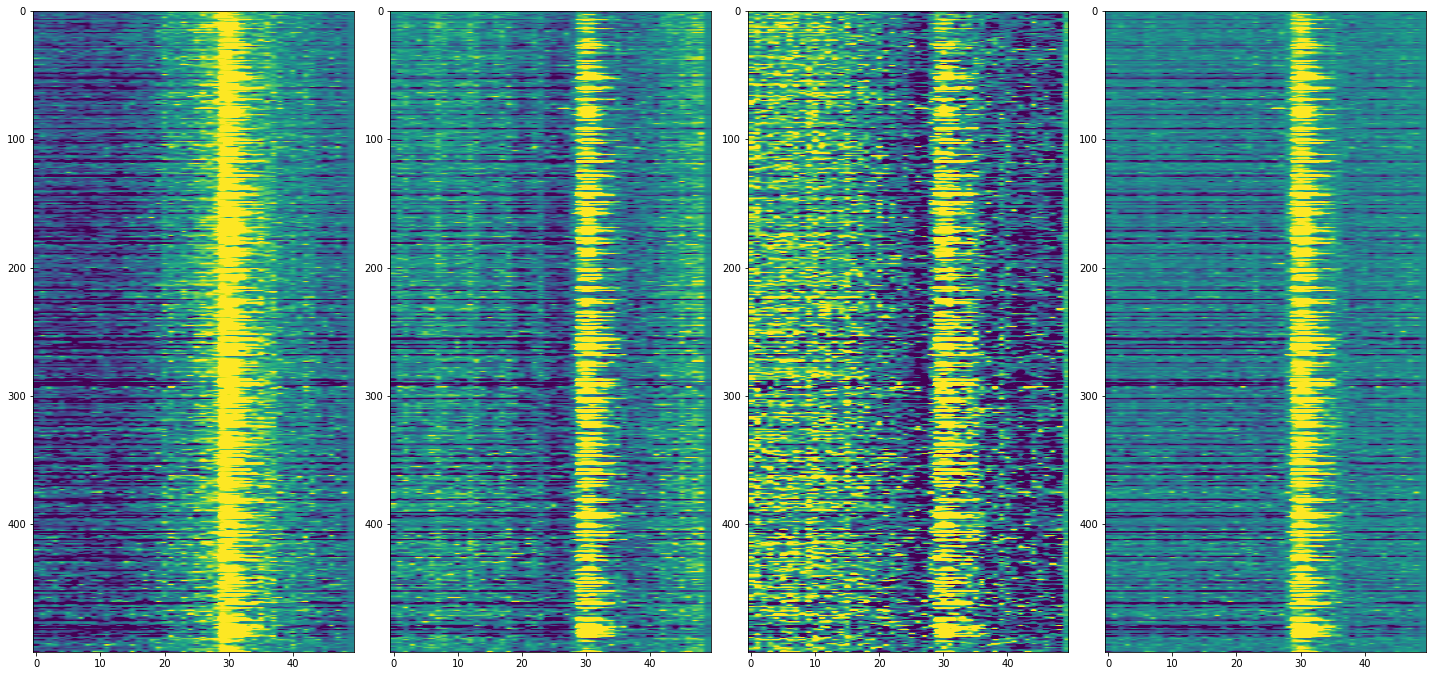

In [20]:
# ax_ap=0.1
# superclust_dict=best
# fig,axs=plt.subplots(1,3,figsize=(10,10))
# axs[0].imshow(superclust_dict['inc'], vmax=0.01,vmin=-0.01)
# axs[0].set_aspect(ax_ap)
# axs[1].imshow(superclust_dict['dec'],  vmax=0.01,vmin=-0.01)
# axs[1].set_aspect(ax_ap)
# axs[2].imshow(superclust_dict['flat'],  vmax=0.01,vmin=-0.01)
# axs[2].set_aspect(ax_ap)
# plt.tight_layout()

ax_ap=0.2
start=15
end=40
superclust_dict=five_sec
fig,axs=plt.subplots(1,len(superclust_dict),figsize=(20,10))
axs[0].imshow(superclust_dict['inc'], vmax=0.01,vmin=-0.01)
axs[0].set_aspect(ax_ap)
axs[1].imshow(superclust_dict['dec'],  vmax=0.01,vmin=-0.01)
axs[1].set_aspect(ax_ap)
axs[2].imshow(superclust_dict['flat'],  vmax=0.01,vmin=-0.01)
axs[2].set_aspect(ax_ap)
axs[3].imshow(superclust_dict['total'],  vmax=0.01,vmin=-0.01)
axs[3].set_aspect(ax_ap)
plt.tight_layout()

In [21]:
superclust_dict_z={}
for behavior in five_sec:
    print(behavior)
    signals_total_z=scipy.stats.zscore(five_sec[behavior][:,14:41],axis=1)
    superclust_dict_z[behavior]=signals_total_z

total
inc
dec
flat


In [22]:
full_res_superclust={}
superclust=superclust_dict_z
n_clusters=500
for behave in superclust:
    cluster_brain=superclust[behave]
    brain=cluster_brain.T
    cluster_labels=giant_total_labels.T
    n_tp = brain.shape[0]
    n_clusters = brain.shape[1]
    brain_dims=[314,146,91]

    colored_by_betas = np.zeros((n_tp, brain_dims[0]*brain_dims[1]*brain_dims[2]))
    colored_by_betas = brain[:, cluster_labels]  # Shape: (n_tp, n_voxels)
    colored_by_betas = colored_by_betas.reshape(n_tp, brain_dims[0], brain_dims[1], brain_dims[2])
    #     for cluster_num in range(n_clusters):
    #         cluster_mask = cluster_labels==cluster_num
    # #         print(np.shape(cluster_mask))
    #         colored_by_betas[:,cluster_mask] = brain[:,cluster_num,np.newaxis]
    colored_by_betas = colored_by_betas.reshape(n_tp,brain_dims[0],brain_dims[1],brain_dims[2])
    full_res_superclust[behave]=np.asarray(colored_by_betas)

In [23]:
roi_atlas = brainsss.load_roi_atlas()
explosion_rois = brainsss.load_explosion_groups()
all_rois = brainsss.unnest_roi_groups(explosion_rois)
roi_masks = brainsss.make_single_roi_masks(all_rois, roi_atlas)
roi_contours = brainsss.make_single_roi_contours(roi_masks, roi_atlas)

In [24]:
full_res_superclust[behavior].shape

(27, 314, 146, 91)

In [25]:
total_vox_sorted={}
for behavior in full_res_superclust:
    STA=np.moveaxis(full_res_superclust[behavior],0,-1)
    total_vox_sorted[behavior]={}
    for area in explosion_rois:
        for key in explosion_rois[area]['rois']:
            area_name=explosion_rois[area]['rois'][key]
            if '_R' in area_name or '_L' in area_name:
                total_area_name=area_name.split('_')
                if len(total_area_name)==3:
                    area_name=total_area_name[0]+'_'+total_area_name[1]
                else:
                    area_name=total_area_name[0]
            roi=key
            roi_mask=roi_masks[roi]
#             print(np.shape(STA))
            masked_roi=[STA[...,i][roi_mask] for i in range(np.shape(STA)[-1])]
            masked_roi=np.transpose(masked_roi)
    #         roi_sort=sort_rows_by_max_index(masked_roi)
            try:
                np.append(total_vox_sorted[behavior][area_name], masked_roi)
            except KeyError:
                total_vox_sorted[behavior][area_name]=masked_roi

In [26]:
total_vox_sorted[behavior].keys()

dict_keys(['FB', 'NO', 'BU', 'LAL', 'PVLP', 'VES', 'EPA', 'GOR', 'AMMC', 'PB', 'EB', 'PRW', 'SAD', 'GNG', 'AVLP', 'AL', 'MB_PED', 'MB_VL', 'MB_ML', 'MB_CA', 'IVLP', 'CAN', 'FLA', 'SLP', 'SMP', 'PLP', 'LH', 'IPS', 'SPS', 'CRE', 'SCL', 'ICL', 'ATL', 'IB', 'SIP', 'MED', 'LO', 'LP', 'AOTU'])

In [27]:
def get_rois(explosion_rois, roi_group, roi_masks, data_to_plot, roi_contours, vmax, cmap, diverging, roi=None):
    x_shift = explosion_rois[roi_group]['x_shift']
    y_shift = explosion_rois[roi_group]['y_shift']

    roi_data = []
    left_edges = []
    right_edges = []
    bottom_edges = []
    top_edges = []

    if roi==None:
        for roi in explosion_rois[roi_group]['rois']:
            mask = roi_masks[roi]
            masked_roi = mask[...,np.newaxis]*data_to_plot # for 3 channel
#             masked_roi = mask*data_to_plot

            ### maximum projection along z-axis
            # works for negative values
            maxs = np.max(masked_roi,axis=2)
            mins = np.min(masked_roi,axis=2)
            maxs[np.where(np.abs(mins)>maxs)] = mins[np.where(np.abs(mins)>maxs)]
            roi_data.append(maxs)
            #masked_roi_flat = maxs

            ### maximum projection along z-axis
            #masked_roi_flat = np.max(masked_roi,axis=2)
            #roi_data.append(masked_roi_flat)

            left_edges.append(roi_contours[roi]['left_edge'])
            right_edges.append(roi_contours[roi]['right_edge'])
            top_edges.append(roi_contours[roi]['top_edge'])
            bottom_edges.append(roi_contours[roi]['bottom_edge'])
    else:
        mask = roi_masks[roi]
        masked_roi = mask[...,np.newaxis]*data_to_plot # for 3 channel
#         masked_roi = mask*data_to_plot

        ### maximum projection along z-axis
        # works for negative values
        maxs = np.max(masked_roi,axis=2)
        mins = np.min(masked_roi,axis=2)
        maxs[np.where(np.abs(mins)>maxs)] = mins[np.where(np.abs(mins)>maxs)]
        roi_data.append(maxs)
        #masked_roi_flat = maxs

        ### maximum projection along z-axis
        #masked_roi_flat = np.max(masked_roi,axis=2)
        #roi_data.append(masked_roi_flat)

        left_edges.append(roi_contours[roi]['left_edge'])
        right_edges.append(roi_contours[roi]['right_edge'])
        top_edges.append(roi_contours[roi]['top_edge'])
        bottom_edges.append(roi_contours[roi]['bottom_edge'])


    # get extreme edges from all rois used
    left_edge = np.min(left_edges) - 1
    right_edge = np.max(right_edges) + 1
    top_edge = np.min(top_edges) - 1
    bottom_edge = np.max(bottom_edges) + 1

    ### this projects across all the roi_data from each roi 
    #roi_datas = np.max(np.asarray(roi_data),axis=0) # this one line is sufficient for not diverging
    maxs = np.max(np.asarray(roi_data),axis=0)
    mins = np.min(np.asarray(roi_data),axis=0)
    maxs[np.where(np.abs(mins)>maxs)] = mins[np.where(np.abs(mins)>maxs)]
    roi_datas = maxs

    ###ADD MAX MIN HERE LIKE ABOVE

    ### cutout this grouping
    #data_map = np.swapaxes(roi_datas[top_edge:bottom_edge,left_edge:right_edge,:],0,1) # for 3 channel
    data_map = np.swapaxes(roi_datas[top_edge:bottom_edge,left_edge:right_edge],0,1)
    ### apply gain
    #data_map = data_map * gain

    mycmap = matplotlib.cm.get_cmap(cmap)
    #mycmap.set_bad('k',1) # make nans black

    if diverging:
        # this will normalize all value to [0,1], with 0.5 being the new "0" basically
        # current issue - a zero that should be background now looks like negative.
        # solution: could use nans instead and set bad color
        # with diverging we should make background white!
        # so actually just set the input_canvas as 0.5!!!
        # then make contours nan and set back as black
        norm = matplotlib.colors.Normalize(vmin=-vmax, vmax=vmax)
        data_map = norm(data_map)
    else:
        data_map = data_map/vmax

    data_map = mycmap(data_map)[...,:3] #lose alpha channel

#     dims = get_dim_info(data_map, full_x_mid, full_y_mid)
    return data_map

In [28]:
color_map_color_1=np.asarray(['#780000','#C1121F','#E0898F','#F0C4C7','#FFFFFF','#D9E6EF','#B3CDDE','#669BBC', '#003049'])[::-1]
cmap_personal = matplotlib.colors.LinearSegmentedColormap.from_list(
    'cmap', color_map_color_1)

top_color=np.asarray(['#780000','#C1121F','#E0898F','#F0C4C7'])[::-1]
bottom=np.asarray(['#D9E6EF','#B3CDDE','#669BBC', '#003049'])[::-1]
top_half_spect = matplotlib.colors.LinearSegmentedColormap.from_list(
    'top_half_spect', top_color)
bottom_half_spect = matplotlib.colors.LinearSegmentedColormap.from_list(
    'bottom_half_spect', bottom)

# Register the new colormap
plt.register_cmap(cmap=top_half_spect)
plt.register_cmap(cmap=bottom_half_spect)

In [29]:
def mean_edges(flattened):
    mean_line=np.nanmean(flattened)
    std=np.nanstd(flattened)
    neg_edge=mean_line-std
    pos_edge=mean_line+std
    return mean_line, neg_edge, pos_edge

In [30]:
t,x,y,z=np.shape(full_res_superclust[behavior])
flatten=np.asarray(full_res_superclust[behavior]).reshape(x*y*z,t)

In [31]:
m,n,p=mean_edges(flatten)

In [32]:
np.mean(flatten)

3.022667319734311e-16

In [33]:
print(explosion_rois['ventromedial_l_group'])
print(np.shape(all_rois))
print(roi_masks.keys())
print(len(roi_contours.keys()))

{'rois': {60: 'VES_L', 85: 'EPA_L', 80: 'GOR_L', 58: 'AMMC_L'}, 'x_shift': 50, 'y_shift': 55}
(71,)
dict_keys([26, 4, 5, 54, 8, 56, 31, 76, 13, 40, 35, 11, 60, 85, 80, 58, 6, 23, 50, 9, 49, 30, 75, 24, 70, 64, 65, 66, 81, 17, 18, 19, 36, 32, 77, 10, 20, 57, 67, 27, 29, 33, 7, 38, 37, 16, 39, 12, 15, 14, 28, 72, 74, 78, 55, 83, 82, 63, 84, 59, 62, 61, 73, 25, 71, 3, 53, 22, 69, 34, 79])
71


In [34]:
roi_label_dict={}
for area in explosion_rois:
    rois=explosion_rois[area]['rois']
    shifts=[explosion_rois[area]['x_shift'], explosion_rois[area]['y_shift']]
    for roi in rois:
        name=rois[roi]
        if area!=name:
            group=area
        else:
            group=name
        roi_label_dict[name]={}
        roi_label_dict[name]['label']=roi
        roi_label_dict[name]['shifts']=shifts
        roi_label_dict[name]['group']=group
            
    

In [35]:
roi_label_dict.keys()

dict_keys(['FB', 'NO', 'BU_R', 'BU_L', 'LAL_R', 'LAL_L', 'PVLP_R', 'PVLP_L', 'VES_R', 'EPA_R', 'GOR_R', 'AMMC_R', 'VES_L', 'EPA_L', 'GOR_L', 'AMMC_L', 'PB', 'EB', 'PRW', 'SAD', 'GNG', 'AVLP_R', 'AVLP_L', 'AL_R', 'AL_L', 'MB_PED_L', 'MB_VL_L', 'MB_ML_L', 'MB_CA_L', 'MB_PED_R', 'MB_VL_R', 'MB_ML_R', 'MB_CA_R', 'IVLP_R', 'IVLP_L', 'CAN_R', 'FLA_R', 'CAN_L', 'FLA_L', 'SLP_R', 'SMP_R', 'PLP_R', 'LH_R', 'IPS_R', 'SPS_R', 'CRE_R', 'SCL_R', 'ICL_R', 'ATL_R', 'IB_R', 'SIP_R', 'SLP_L', 'SMP_L', 'PLP_L', 'LH_L', 'IPS_L', 'SPS_L', 'CRE_L', 'SCL_L', 'ICL_L', 'ATL_L', 'IB_L', 'SIP_L', 'MED_R', 'MED_L', 'LO_R', 'LO_L', 'LP_R', 'LP_L', 'AOTU_R', 'AOTU_L'])

In [36]:
for b in full_res_superclust:
    full_res_superclust[b]=np.moveaxis(full_res_superclust[b],0,-1)

In [37]:
def get_vals_anat(roi, roi_label_dict, roi_masks, traces, behavior, roi_contours, vmax, thresh=None):
    x_shift = roi_label_dict[roi]['shifts'][0]
    y_shift = roi_label_dict[roi]['shifts'][1]

    left_edges = []
    right_edges = []
    bottom_edges = []
    top_edges = []
    
    roi_label=roi_label_dict[roi]['label']
    mask = roi_masks[roi_label]
    masked_roi = np.where(mask[...,None]==True, traces[behavior], np.nan)
#     t,x,y,z=np.shape(masked_roi)
    x,y,z,t=np.shape(traces[behavior])
#     flatten=np.asarray(masked_roi).reshape(x*y*z,t)
    flatten=np.asarray(traces[behavior]).reshape(x*y*z,t)
    m,n,p=mean_edges(flatten)
    
    if thresh=='pos':
        total_masked=np.where(masked_roi>p*1,masked_roi, np.nan)
#         print(p)
    elif thresh=='neg':
        total_masked=np.where(masked_roi<n*1,masked_roi, np.nan)
#         print(n)
    elif thresh != None:
        total_masked=np.where(masked_roi>thresh,masked_roi, np.nan)
    else:
        total_masked=masked_roi
    
    left_edges.append(roi_contours[roi_label]['left_edge'])
    right_edges.append(roi_contours[roi_label]['right_edge'])
    top_edges.append(roi_contours[roi_label]['top_edge'])
    bottom_edges.append(roi_contours[roi_label]['bottom_edge'])
    
    # get extreme edges from all rois used
    left_edge = np.min(left_edges) - 1
    right_edge = np.max(right_edges) + 1
    top_edge = np.min(top_edges) - 1
    bottom_edge = np.max(bottom_edges) + 1
    
    final=total_masked[top_edge:bottom_edge,left_edge:right_edge]
#     norm = matplotlib.colors.Normalize(vmin=-vmax, vmax=vmax)
#     final = norm(final)

    contour = roi_contours[roi_label]['contour'][...,0]
    contour = contour[top_edge:bottom_edge,left_edge:right_edge]
    
    return final, contour

In [38]:
behavior_dict_z['total'].shape

(314, 146, 91, 27)

In [78]:
anat='IPS'
behave='total'
direction=None
total_anat_max_r, contour_max_r=get_vals_anat(f'{anat}_R', roi_label_dict, roi_masks, behavior_dict_z, behave, roi_contours, vmax=None, thresh=direction)
total_anat_max_l, contour_max_l=get_vals_anat(f'{anat}_L', roi_label_dict, roi_masks, behavior_dict_z, behave, roi_contours, vmax=None, thresh=direction)
# total_anat_max, contour_max=get_vals_anat(f'{anat}', roi_label_dict, roi_masks, behavior_dict_z, behave, roi_contours, vmax=None, thresh=direction)

In [79]:
# direction='neg'
# total_anat_min_r, contour_min_r=get_vals_anat(f'{anat}_R', roi_label_dict, roi_masks, behavior_dict_z, behave, roi_contours, vmax=None, thresh=direction)
# total_anat_min_l, contour_min_l=get_vals_anat(f'{anat}_L', roi_label_dict, roi_masks, behavior_dict_z, behave, roi_contours, vmax=None, thresh=direction)
# # total_anat_min, contour_min=get_vals_anat(f'{anat}', roi_label_dict, roi_masks, behavior_dict_z, behave, roi_contours, vmax=None, thresh=direction)

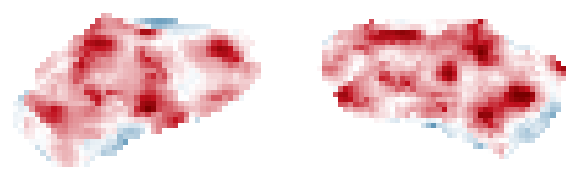

In [80]:
t=25
vmax=3
final_r=np.nanmax(total_anat_max_r[...,t],axis=-1)
final_l=np.nanmax(total_anat_max_l[...,t],axis=-1)
fig, axs=plt.subplots(1,2,figsize=(10,10))
axs[0].imshow(contour_max_r.T, 'Greys');
axs[0].imshow(final_r.T, cmap=cmap_personal,norm=matplotlib.colors.Normalize(vmin=-vmax, vmax=vmax));
axs[0].axis('off');
axs[1].imshow(contour_max_l.T, 'Greys');
axs[1].imshow(final_l.T, cmap=cmap_personal, norm=matplotlib.colors.Normalize(vmin=-vmax, vmax=vmax));
axs[1].axis('off');
# plt.savefig(os.path.join(save_dir,f'{anat}_{t}_{behave}.png'), dpi=300, bbox_inches='tight')
# plt.savefig(os.path.join(save_dir,f'{anat}_{t}_{behave}.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)

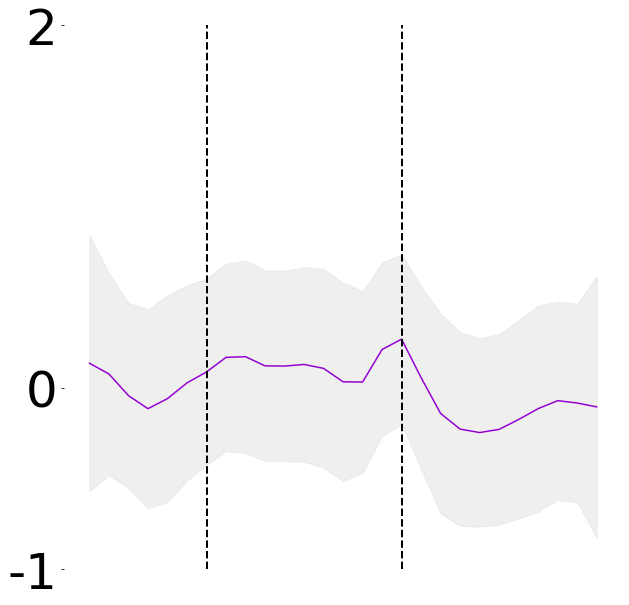

In [81]:
smoothed=gaussian_filter1d(np.vstack([total_anat_max_r.reshape(-1,27),total_anat_max_l.reshape(-1,27)]), sigma=1)
# smoothed=gaussian_filter1d(total_anat_max.reshape(-1,27), sigma=1)
avg_trace=np.nanmean(smoothed,axis=0)
error_trace=np.nanstd(smoothed,axis=0)
fig,ax=plt.subplots(figsize=(10,10));
ax.plot(avg_trace, color='#9400D3')
ax.fill_between(np.arange(len(avg_trace)),avg_trace-error_trace, avg_trace+error_trace, color='#e0e0df',alpha=0.5)
x1=6;x2=16
ax.axvline(x=x1, ymin=0, ymax=1, ls='--', color='k', lw=2)
ax.axvline(x=x2, ymin=0, ymax=1, ls='--', color='k', lw=2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_xticks([])
# ax.set_xticklabels([-0.5,0,1,2])
ax.set_yticks([-1,0,2])
ax.set_yticklabels([-1,0,2])
ax.set_ylim(-1,2)
ax.tick_params(axis='y', labelsize=50) 
# plt.savefig(os.path.join(save_dir,f'{anat}_voxplot_100.png'), dpi=300, bbox_inches='tight')
# plt.savefig(os.path.join(save_dir,f'{anat}_voxplot_100.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)

In [43]:
t=3
vmax=3
final=np.nanmax(total_anat_max[...,t],axis=-1)
fig, axs=plt.subplots(1,figsize=(10,10))
axs.imshow(contour_max.T, 'Greys');
axs.imshow(final.T, cmap=cmap_personal,norm=matplotlib.colors.Normalize(vmin=-vmax, vmax=vmax));
axs.axis('off');
# plt.savefig(os.path.join(save_dir,f'{anat}_{t}_{behave}.png'), dpi=300, bbox_inches='tight')
# plt.savefig(os.path.join(save_dir,f'{anat}_{t}_{behave}.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)

NameError: name 'total_anat_max' is not defined

In [ ]:
# ts=[6,7,8,9,10,11,12,13,14,15]
# ts=[2,14,15,17]
ts=25
num_reg=1
fig, axs=plt.subplots(1,2,figsize=(10,10))
anat_max=total_anat_max_r
anat_min=total_anat_min_r
x,y=np.nanmax(anat_max[...,ts],axis=-1).shape
max_t=np.ravel(np.nanmax(anat_max[...,ts],axis=-1))
min_t=np.ravel(np.nanmin(anat_min[...,ts],axis=-1))
for i in range(min_t.shape[0]):
    if ~np.isnan(max_t[i]) and ~np.isnan(min_t[i]):
        if np.abs(max_t[i])>np.abs(min_t[i]):
            min_t[i]=np.nan
        elif np.abs(max_t[i])<np.abs(min_t[i]):
            max_t[i]=np.nan
final_max=max_t.reshape(x,y)
final_min=min_t.reshape(x,y)
axs[0].imshow(contour_max_r.T, 'Greys');

axs[0].imshow(final_min.T, cmap=bottom_half_spect);
axs[0].imshow(final_max.T,cmap=top_half_spect);

axs[0].axis('off');
anat_max=total_anat_max_l
anat_min=total_anat_min_l
x,y=np.nanmax(anat_max[...,ts],axis=-1).shape
max_t=np.ravel(np.nanmax(anat_max[...,ts],axis=-1))
min_t=np.ravel(np.nanmin(anat_min[...,ts],axis=-1))
for i in range(min_t.shape[0]):
    if ~np.isnan(max_t[i]) and ~np.isnan(min_t[i]):
        if np.abs(max_t[i])>np.abs(min_t[i]):
            min_t[i]=np.nan
        elif np.abs(max_t[i])<np.abs(min_t[i]):
            max_t[i]=np.nan
final_max=max_t.reshape(x,y)
final_min=min_t.reshape(x,y)
axs[1].imshow(contour_max_l.T, 'Greys');

axs[1].imshow(final_min.T, cmap=bottom_half_spect);
axs[1].imshow(final_max.T,cmap=top_half_spect);

axs[1].axis('off');
# plt.savefig(os.path.join(save_dir,f'{anat}_{ts}_{behave}.png'), dpi=300, bbox_inches='tight')
# plt.savefig(os.path.join(save_dir,f'{anat}_{ts}_{behave}.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)

In [ ]:
t=3
num_reg=1
fig, axs=plt.subplots(figsize=(10,10))
anat_max=total_anat_max
anat_min=total_anat_min
x,y=np.nanmax(anat_max[...,t],axis=-1).shape
max_t=np.ravel(np.nanmax(anat_max[...,t],axis=-1))
min_t=np.ravel(np.nanmin(anat_min[...,t],axis=-1))
for i in range(min_t.shape[0]):
    if ~np.isnan(max_t[i]) and ~np.isnan(min_t[i]):
        if np.abs(max_t[i])>np.abs(min_t[i]):
            min_t[i]=np.nan
        elif np.abs(max_t[i])<np.abs(min_t[i]):
            max_t[i]=np.nan
final_max=max_t.reshape(x,y)
final_min=min_t.reshape(x,y)
axs.imshow(contour_max.T, 'Greys');

axs.imshow(final_min.T, cmap=bottom_half_spect);
axs.imshow(final_max.T,cmap=top_half_spect);
axs.axis('off');
# plt.savefig(os.path.join(save_dir,f'{anat}_{t}_{behave}.png'), dpi=300, bbox_inches='tight')
# plt.savefig(os.path.join(save_dir,f'{anat}_{t}_{behave}.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)